# Transmission Spectrum Basics

The atmospheric components from notebook 2 are now ready to be turned into a spectrum. This notebook assembles the first complete forward model in the series: a transmission geometry, where starlight grazes the planet's limb and the wavelength-dependent opacity of the atmosphere stamps its signature onto the light. Notebook 4 works through the same steps for emission, and notebooks 5 and 7 extend this setup further.

In transmission, the effective area blocked by the planet at each wavelength depends on how high in the atmosphere the gas becomes optically thick. Wavelengths that overlap with strong molecular absorption bands probe higher, cooler layers and show a larger transit depth.

This notebook builds a `TransmissionModel` step by step and then shows how adding radiative contributions — molecular absorption first, then CIA and Rayleigh scattering — reshapes the spectrum. More information about forward models is [here](../user/taurex/models.rst), planet parameters are [here](../user/taurex/planet.rst), and star parameters are [here](../user/taurex/star.rst).

## Data Note

This notebook uses the opacity and CIA files set up in notebook 1. TauREx provides the software to work with these datasets; the files themselves are third-party products from [ExoMol](https://www.exomol.com) and [HITRAN](https://hitran.org/).

In [1]:
from _shared import build_base_components
from taurex.constants import RSOL

context = build_base_components(download=False)
iso_t = context['iso_t']
press = context['press']
chemistry = context['chemistry']
planet = context['planet']
star = context['star']

print(f'Planet: {planet.mass:.2f} M_jup, {planet.radius:.2f} R_jup')
print(f'Star: {star.temperature:.0f} K, {star.radius / RSOL:.2f} R_sun')


Planet: 0.74 M_jup, 1.38 R_jup
Star: 6117 K, 1.16 R_sun


## Building the Model

Assembling a `TransmissionModel` connects the atmosphere from notebook 2 with a planet and a host star. Each physical process — molecular absorption, CIA, Rayleigh scattering, clouds — is added as an independent **contribution** object, which keeps the code composable and easy to extend.

The model must be explicitly `build()`-ed before running. Calling `build()` again after adding or removing a contribution refreshes the radiative-transfer kernel. More information about forward models is [here](../user/taurex/models.rst), planet parameters are [here](../user/taurex/planet.rst), and star parameters are [here](../user/taurex/star.rst).

In [2]:
from taurex.model import TransmissionModel
from taurex.contributions import AbsorptionContribution

tm = TransmissionModel(
    planet=planet,
    temperature_profile=iso_t,
    chemistry=chemistry,
    star=star,
    pressure_profile=press,
)
tm.add_contribution(AbsorptionContribution())
tm.build()

print('Contributions:', [c.name for c in tm.contribution_list])

Contributions: ['Absorption']


In [3]:
wngrid, rprs, tau, _ = tm.model()
wlgrid = 10000 / wngrid[::-1]
abs_only_rprs = rprs[::-1]

print(f'Computed {len(wngrid)} spectral points.')
print(f'Wavelength range: {wlgrid.min():.3f} to {wlgrid.max():.3f} um')

Computed 76744 spectral points.
Wavelength range: 0.300 to 50.002 um


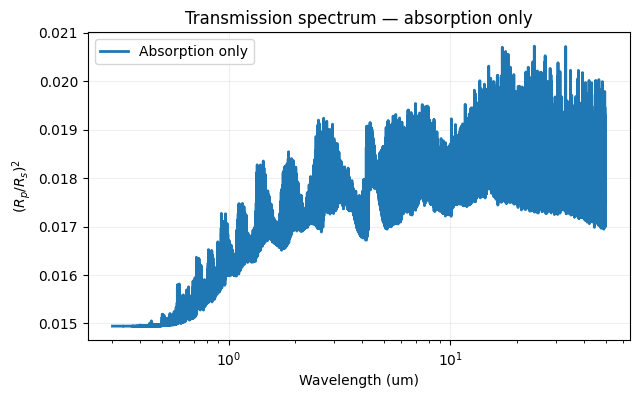

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(wlgrid, abs_only_rprs, lw=2, label='Absorption only')
plt.xscale('log')
plt.xlabel('Wavelength (um)')
plt.ylabel('$(R_p/R_s)^2$')
plt.title('Transmission spectrum — absorption only')
plt.legend()
plt.grid(alpha=0.2)

## CIA and Rayleigh Scattering

With absorption-only features in place, two more fundamental processes fill in the spectral baseline. Collision-Induced Absorption (CIA) from H₂–H₂ and H₂–He pairs adds a smooth continuum at long wavelengths, while Rayleigh scattering raises the transit depth in the blue. Each is added as a separate contribution and the model is rebuilt to register it.

Notebook 5 extends this model with cloud opacities. More information about available contributions is [here](../user/taurex/models.rst).

In [ ]:
from taurex.cache import CIACache
from taurex.contributions import CIAContribution, RayleighContribution
from _shared import CIA_DIR, TMP_DIR

clean_cia_dir = TMP_DIR / 'cia_clean'
clean_cia_dir.mkdir(parents=True, exist_ok=True)

for source_path in CIA_DIR.glob('*.cia'):
    cleaned = [
        f"H2-H2 {line.split(maxsplit=3)[-1]}"
        if line.lstrip().startswith('eq-H2 -- eq-H2')
        else line
        for line in source_path.read_text().splitlines(keepends=True)
    ]
    (clean_cia_dir / source_path.name).write_text(''.join(cleaned))

cia_cache = CIACache()
cia_cache.cia_dict.clear()
cia_cache.set_cia_path(str(clean_cia_dir))

# Keep the cell rerunnable by starting from absorption only.
tm.contribution_list = tm.contribution_list[:1]

spectra = {}
for contribution, key in [
    (CIAContribution(cia_pairs=['H2-H2', 'H2-He']), 'cia'),
    (RayleighContribution(), 'full'),
]:
    tm.add_contribution(contribution)
    tm.build()
    spectra[key] = tm.model()[1][::-1]

rprs_cia = spectra['cia']
rprs_full = spectra['full']

print('Contributions:', [c.name for c in tm.contribution_list])

Contributions: ['Absorption', 'CIA', 'Rayleigh']


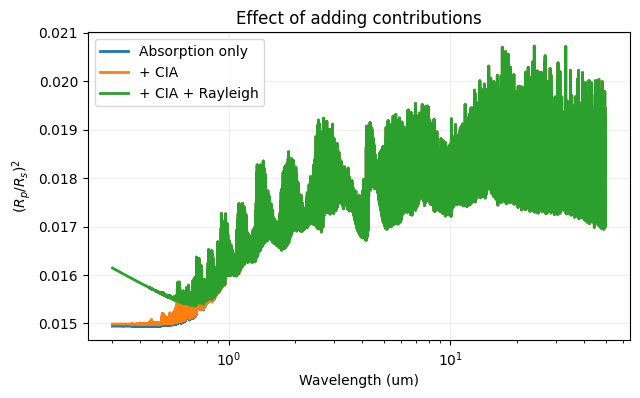

In [6]:
plt.figure(figsize=(7, 4))
plt.plot(wlgrid, abs_only_rprs, lw=2, label='Absorption only')
plt.plot(wlgrid, rprs_cia, lw=2, label='+ CIA')
plt.plot(wlgrid, rprs_full, lw=2, label='+ CIA + Rayleigh')
plt.xscale('log')
plt.xlabel('Wavelength (um)')
plt.ylabel('$(R_p/R_s)^2$')
plt.title('Effect of adding contributions')
plt.legend()
plt.grid(alpha=0.2)

## Reading the Spectrum

Each point on the transit-depth curve encodes the altitude at which the atmosphere becomes opaque at that wavelength. A higher transit depth means the planet is blocking a larger cross-section of the stellar disc — typically because a strong absorber is present at altitude.

- **Molecular absorption** produces the narrow, prominent features: peaks at wavelengths where individual gases absorb strongly.
- **CIA** adds a smooth continuum offset, most noticeable at the red end of the spectrum.
- **Rayleigh scattering** lifts the spectrum at short wavelengths, producing a characteristic blue slope.